*Кузнецов РТ5-61Б*

## Задача

Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель.

In [1]:
# Импорт библиотек, которые нам потребуются
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка данных

In [2]:
data = pd.read_csv('HousingData.csv', sep = ",")

data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [3]:
# Форма датасета

data.shape

(506, 14)

In [4]:
# Статистическое описание датасета

data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [5]:
# Типы колонок

data.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Проведем текстовое описание признаков датасета:

* CRIM - преступность на душу населения по городу
* ZN - доля жилой земли, отведенной под участки площадью более 25 000 кв. футов
* INDUS - доля акров земли в городе, занятой предприятиями, не относящимися к розничной торговле
* CHAS - переменная-заглушка реки Чарльз (1 - территория включает реку, 0 в противном случае)
* NOX - концентрация нитритных оксидов (частей на 10 миллионов)
* RM - среднее число комнат в каждом жилище
* AGE - пропорция домов, в которых проживают их владельцы, построенных до 1940 года
* DIS - взвешенное расстояние до пяти районных центров Бостона
* RAD - индекс доступности радиальных шоссе
* TAX - ставка налога на недвижимость оцениваемая по номинальной стоимости (долларов на 10 000 долларов)
* PTRATIO - отношение числа учеников к числу учителей по городу
* B - 1000(Bk - 0.63)^2, где Bk - доля темнокожих в городе
* LSTAT - % людей низкого статуса в популяции
* MEDV - медианная стоимость домов, в которых проживают их владельцы (в тысячах долларов)

Все данные числовые, единственное требуемое преобразование - исключение пропусков. Исключим строки с пропусками, так как пропуски присутствуют во многих столбцах.

In [7]:
data =  data.dropna()

data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000
mean,3.690136,11.460660,11.000863,0.068528,0.553215,6.280015,68.932741,3.805268,9.403553,406.431472,18.537563,358.490939,12.769112,22.359645
std,9.202423,23.954082,6.908364,0.252971,0.113112,0.697985,27.888705,2.098571,8.633451,168.312419,2.166460,89.283295,7.308430,9.142979
min,0.006320,0.000000,0.460000,0.000000,0.389000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,2.600000,1.730000,5.000000
25%,0.081955,0.000000,5.130000,0.000000,0.453000,5.879250,45.475000,2.110100,4.000000,280.250000,17.400000,376.707500,7.125000,16.800000
50%,0.268880,0.000000,8.560000,0.000000,0.538000,6.201500,77.700000,3.199200,5.000000,330.000000,19.100000,392.190000,11.300000,21.050000
75%,3.435973,12.500000,18.100000,0.000000,0.624000,6.605500,94.250000,5.116700,24.000000,666.000000,20.200000,396.900000,17.117500,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Корреляционный анализ

Проведем корреляционный анализ данных. Сначала оценим применимость коэффициента Пирсона - посмотрим, нормально ли распределены данные.

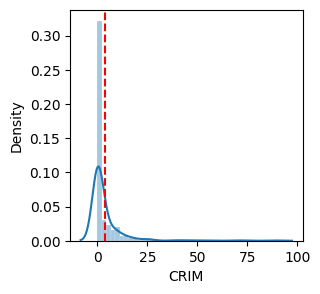

In [8]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['CRIM'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['CRIM'].mean(), color='red', linestyle='--')

Данные имеют выбросы, на что может негативно отреагировать коэффициент Пирсона.

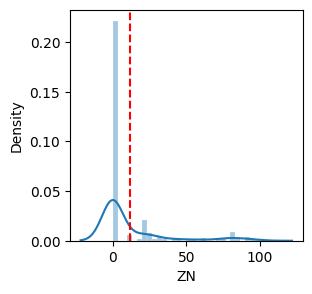

In [9]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['ZN'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['ZN'].mean(), color='red', linestyle='--')

Колонка ZN также имеет выбросы.

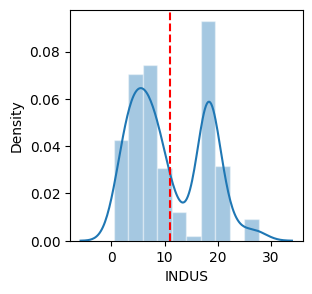

In [10]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['INDUS'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['INDUS'].mean(), color='red', linestyle='--')

Данные колонки INDUS бимодальны. 

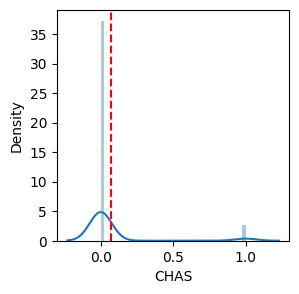

In [11]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['CHAS'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['CHAS'].mean(), color='red', linestyle='--')

В колонке CHAS наблюдается слабая бимодальность с выбросами.

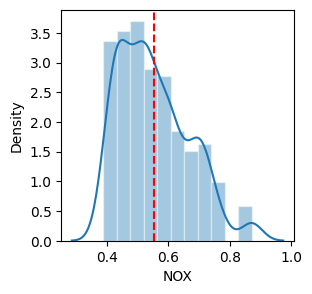

In [12]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['NOX'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['NOX'].mean(), color='red', linestyle='--')

В распределении NOX нет выбросов и ярко выраженной мультимодальности, распределение близко к нормальному.

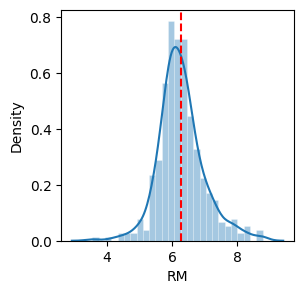

In [13]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['RM'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['RM'].mean(), color='red', linestyle='--')

Распределение RM практически идеально нормальное.

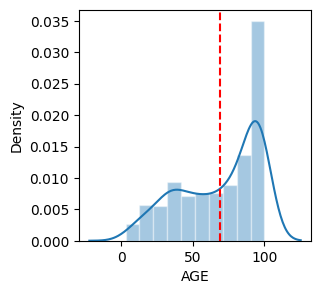

In [14]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['AGE'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['AGE'].mean(), color='red', linestyle='--')

Распределение ассиметричное правостороннее.

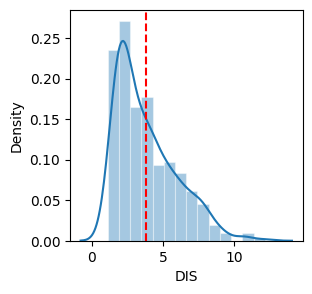

In [15]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['DIS'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['DIS'].mean(), color='red', linestyle='--')

Распределение асимметричное левостороннее.

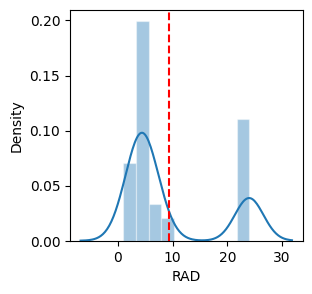

In [16]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['RAD'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['RAD'].mean(), color='red', linestyle='--')

Для графы RAD наблюдается мультимодальность.

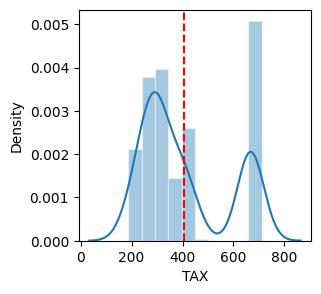

In [17]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['TAX'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['TAX'].mean(), color='red', linestyle='--')

Для графы TAX также наблюдается бимодальность.

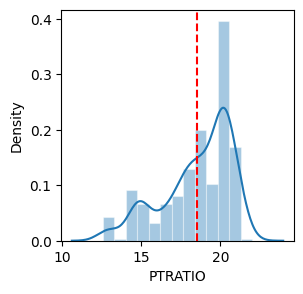

In [18]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['PTRATIO'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['PTRATIO'].mean(), color='red', linestyle='--')

Данные распределены не нормально, но отсутвутют выбросы и мультимодальность.

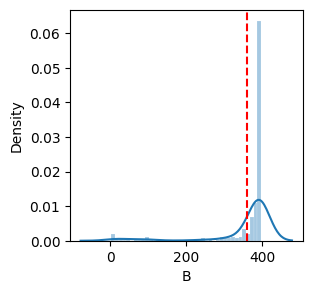

In [19]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['B'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['B'].mean(), color='red', linestyle='--')

В колонке B имеются выбросы.

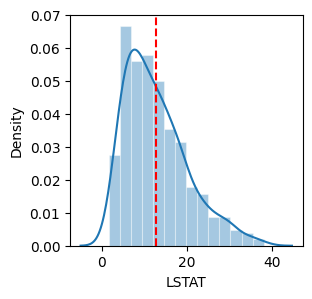

In [20]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['LSTAT'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['LSTAT'].mean(), color='red', linestyle='--')

Распределение признака LSTAT близко к нормальному.

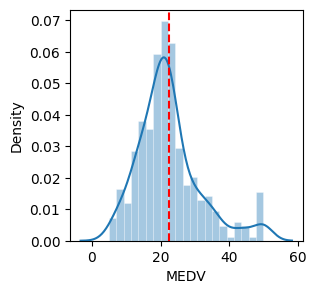

In [21]:
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(    
    data['MEDV'], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4))
# Нанесем на график среднее значение признака
plt.axvline(data['MEDV'].mean(), color='red', linestyle='--')

В силу присутствия выбросов во многих столбцах, а также характера их распределения, коэффициент Пирсона может оказаться недостаточно информативным. Выводы о корреляциях будем делать по нему и по коэффициенту Кендалла.

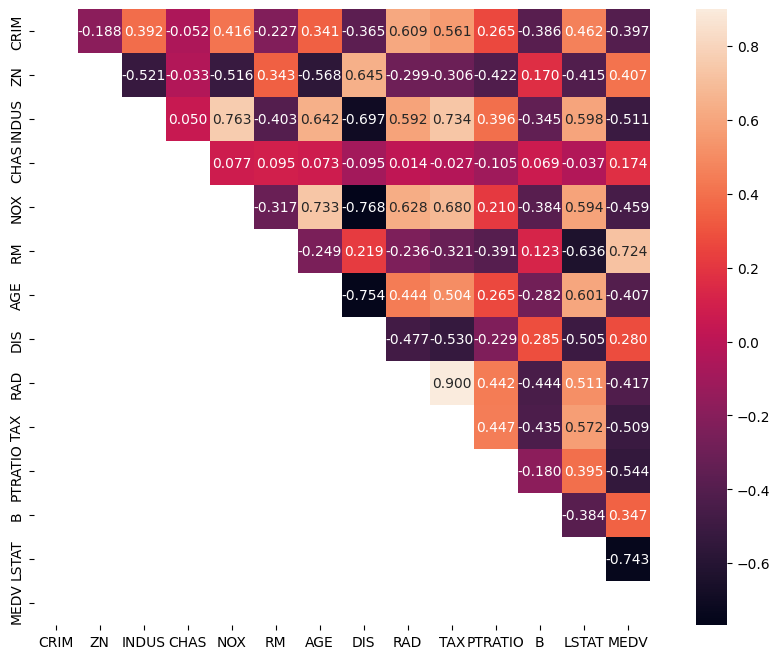

In [22]:
# Треугольный вариант матрицы
mask = np.zeros_like(data.corr(), dtype=np.bool)
# чтобы оставить нижнюю часть матрицы
# mask[np.triu_indices_from(mask)] = True
# чтобы оставить верхнюю часть матрицы
mask[np.tril_indices_from(mask)] = True

plt.figure(figsize=(12, 8))

sns.heatmap(data.corr(), mask=mask, annot=True, fmt='.3f', square=True)

plt.show()

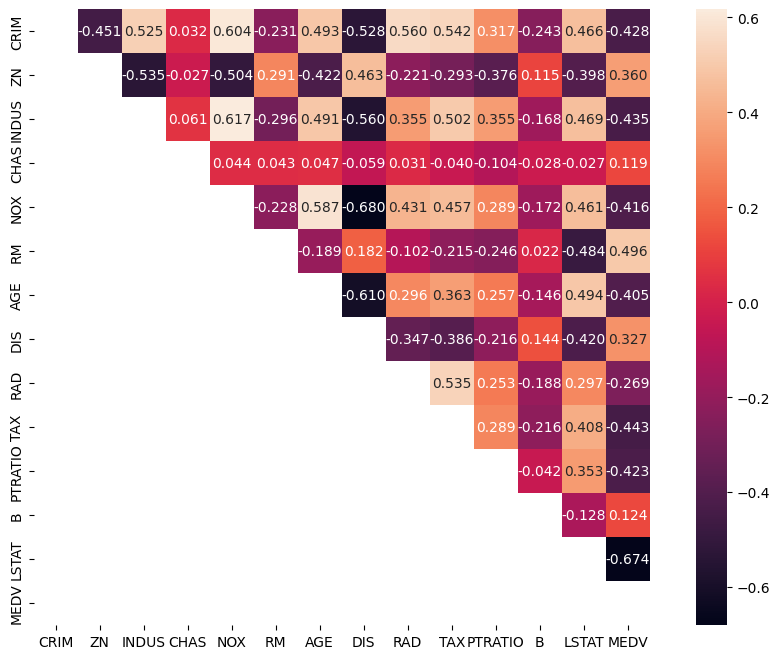

In [23]:
# Треугольный вариант матрицы
mask = np.zeros_like(data.corr(method='kendall'), dtype=np.bool)
# чтобы оставить нижнюю часть матрицы
# mask[np.triu_indices_from(mask)] = True
# чтобы оставить верхнюю часть матрицы
mask[np.tril_indices_from(mask)] = True

plt.figure(figsize=(12, 8))

sns.heatmap(data.corr(method='kendall'), mask=mask, annot=True, fmt='.3f', square=True)

plt.show()

**Выводы**

* Переменная соседства с рекой Чарльз практически не коррелирует ни с каким другим признаком. Слабая связь наблюдается только с MEDV. Признак стоит оставить.

* Целевой признак MEDV показывает сильную отрицательную корреляцию с LSTAT (Пирсон -0.67, Кендалл -0.74). Чем выше доля населения с низким статусом, тем ниже цена жилья. Это самый сильный предиктор в датасете.

* Целевой признак показывает заметную положительную корреляцию с RM (Пирсон 0.50, Кендалл 0.72). Количество комнат — второй по значимости фактор, влияющий на стоимость.

* Целевой признак показывает умеренную отрицательную корреляцию с PTRATIO (Пирсон -0.42, Кендалл -0.54), INDUS (-0.44 / -0.51), TAX (-0.44 / -0.51) и NOX (-0.42 / -0.46). Эти признаки также влияют на цену, но слабее, чем LSTAT и RM.

* Признаки NOX и INDUS имеют сильную связь (Пирсон 0.76, Кендалл 0.62). Это закономерно, так как промышленные зоны являются основным источником загрязнения. Для линейных моделей это проблематично — рекомендуется оставить только один из них. Предпочтение стоит отдать NOX, так как он имеет чуть более сильную корреляцию с MEDV.

* Признаки NOX и DIS сильно отрицательно коррелируют (Пирсон -0.77, Кендалл -0.68). Удалённость от районных центров связана с меньшим уровнем загрязнения. Это ещё один аргумент в пользу того, чтобы в линейной модели оставить только один из этой группы.

* Признаки AGE и DIS также сильно отрицательно коррелируют (Пирсон -0.75, Кендалл -0.61). Старые дома расположены ближе к райцентрам. Это ещё одна группа мультиколлинеарных признаков.

* Особого внимания заслуживает пара RAD и TAX. Здесь наблюдается критическое расхождение между Пирсоном (0.90) и Кендаллом (0.54). Это указывает на то, что сильная линейная связь, скорее всего, обусловлена выбросами. Для линейных моделей использование обоих признаков одновременно не рекомендуется. Предпочтение стоит отдать TAX, так как он сильнее коррелирует с целевым признаком.

* Признаки CRIM и ZN также показывают сильное расхождение между Пирсоном (-0.45) и Кендаллом (-0.19). Это говорит о том, что связь между ними и другими признаками может быть искажена выбросами. Для линейных моделей рекомендуется логарифмировать CRIM и ZN или использовать их в бинарном виде.